# Basic OpenAI Agent with Code Execution

This notebook demonstrates the fundamentals of agentic worfklows using OpenAI's containers to execute Python code and generate visualizations. We'll begin with basic operations, and then proceed to a more realistic example relevant to the broad fields of Civil, Environmental and Applied Earth Engineering: retrieving and plotting streamflow data from USGS (the United States Geological Survey).

---

## Part 1: Basic workflow

We will build agents using the OpenAI platform and containers. To do so, we require an API key which you should have received for this workshop. 


> **Why use containers?**  
Containers provide a **safe, isolated environment** to run code and Python commands. This isolation helps protect your local machine by sandboxing code execution, preventing potentially unsafe or buggy code from affecting your broader system. Using containers is especially important when running code generated dynamically (such as by an agent), as it mitigates risks and allows reproducibility.

In [ ]:
# Imports and Setup
import uuid
from io import BytesIO
from openai import OpenAI
from IPython.display import display, Image, Markdown

# NOTE: Paste your OpenAI API key manually here
api_key = "sk-proj-xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"

# Initialize OpenAI client
client = OpenAI(api_key=api_key)

# Quick API key check
try:
    _ = client.models.list()
    print("✓ API key check succeeded")
except Exception as exc:
    print(f"✗ API key check failed: {exc}")


✓ API key check succeeded


### Creating a Sandbox for Agent Execution

To safely run our agents, we first create an isolated **Code Interpreter container**.  Each container acts as a sandboxed Python environment, preventing side effects and ensuring reproducibility. 

We assign each container a random name to avoid collisions and to make runs easy to track programmatically.

In [2]:
# Create a Code Interpreter Container
# Containers provide an isolated Python environment for code execution
container_name = f"basic-agent-{uuid.uuid4().hex[:8]}"
container = client.containers.create(name=container_name)
container_id = container.id

print(f"✓ Container created: {container_name}")
print(f"  Container ID: {container_id}")

✓ Container created: basic-agent-c98b43e8
  Container ID: cntr_6980b9a3e534819199b2a6364d330e8403523943b5f562b4


### Defining the Agent Instructions and Task

We use two prompts to control the agent’s behavior:

- **System Prompt**: Defines the agent’s role and constraints. Here, it instructs the agent to behave as a Python execution assistant and to always save generated files so outputs can be retrieved.
- **User Prompt**: Specifies the concrete task to perform. In this example, the agent is asked to generate synthetic data, create a well-formatted visualization, save it to disk, and briefly explain the result.

In [3]:
# Define System Prompt and User Prompt
SYSTEM_PROMPT = """You are a Python code execution assistant. 
You help users by writing and executing Python code to accomplish their tasks.
Always save any generated files (figures, data, etc.) so they can be retrieved."""

USER_PROMPT = """Create a beautiful visualization showing the relationship between 
two random variables. 

Requirements:
1. Generate 100 random data points for two variables (x and y) with some correlation
2. Create a scatter plot with a trend line (linear regression)
3. Use matplotlib with a nice color scheme
4. Add proper axis labels, a descriptive title, and a legend
5. Save the figure as 'visualization.png'
"""

print("System Prompt:")
print("-" * 40)
print(SYSTEM_PROMPT)
print("\nUser Prompt:")
print("-" * 40)
print(USER_PROMPT)


System Prompt:
----------------------------------------
You are a Python code execution assistant. 
You help users by writing and executing Python code to accomplish their tasks.
Always save any generated files (figures, data, etc.) so they can be retrieved.

User Prompt:
----------------------------------------
Create a beautiful visualization showing the relationship between 
two random variables. 

Requirements:
1. Generate 100 random data points for two variables (x and y) with some correlation
2. Create a scatter plot with a trend line (linear regression)
3. Use matplotlib with a nice color scheme
4. Add proper axis labels, a descriptive title, and a legend
5. Save the figure as 'visualization.png'



### Sending the Task to the Model (and Running It)

We send the **system** and **user** prompts to the model in a structured format.  
Here we use **GPT-5.2 (a reasoning/thinking model)** together with **Code Interpreter**, so the model does not just write code, but it also **executes the code** to complete the task (e.g., generate data, create the plot, and save `visualization.png`).

In short:
- The **input payload** contains the instructions and the task.
- gpt-5.2 uses **Code Interpreter** to **run Python code**.
- The code runs inside the **container** we created earlier.
- `tool_choice="required"` forces the model to execute code via the tool.
- The returned `response` contains the results of the execution.

In [4]:
# Send Request to OpenAI with Code Interpreter

# Build the input payload
input_payload = [
    {
        "role": "system",
        "content": [{"type": "input_text", "text": SYSTEM_PROMPT}],
    },
    {
        "role": "user", 
        "content": [{"type": "input_text", "text": USER_PROMPT}],
    },
]

# Make the API call with code interpreter tool
print("Sending request to OpenAI...")
print("(This may take some time as the model generates and executes code)\n")

response = client.responses.create(
    model="gpt-5.2",
    input=input_payload,
    tools=[{"type": "code_interpreter", "container": container_id}],
    tool_choice="required",  # Force the model to use the code interpreter
)

print("✓ Response received!")


Sending request to OpenAI...
(This may take some time as the model generates and executes code)

✓ Response received!


### Displaying the Results

After the model has finished running the code, we extract and display the results.

This step does two things:
- Shows the **text response** produced by the model (e.g. explanations).
- Attempts to find any **files created during execution** (e.g., images) and download them from the container so we can display them. This is necessary because code execution can generate files as outputs (like figures), but we cannot be 100% certain in advance which files will be produced, or if file generation will succeed every time. So, we try to discover and fetch the results dynamically.


Assistant Response:
----------------------------------------


Saved the requested visualization here: [Download visualization.png](sandbox:/mnt/data/visualization.png)


Generated Images:
visualization.png


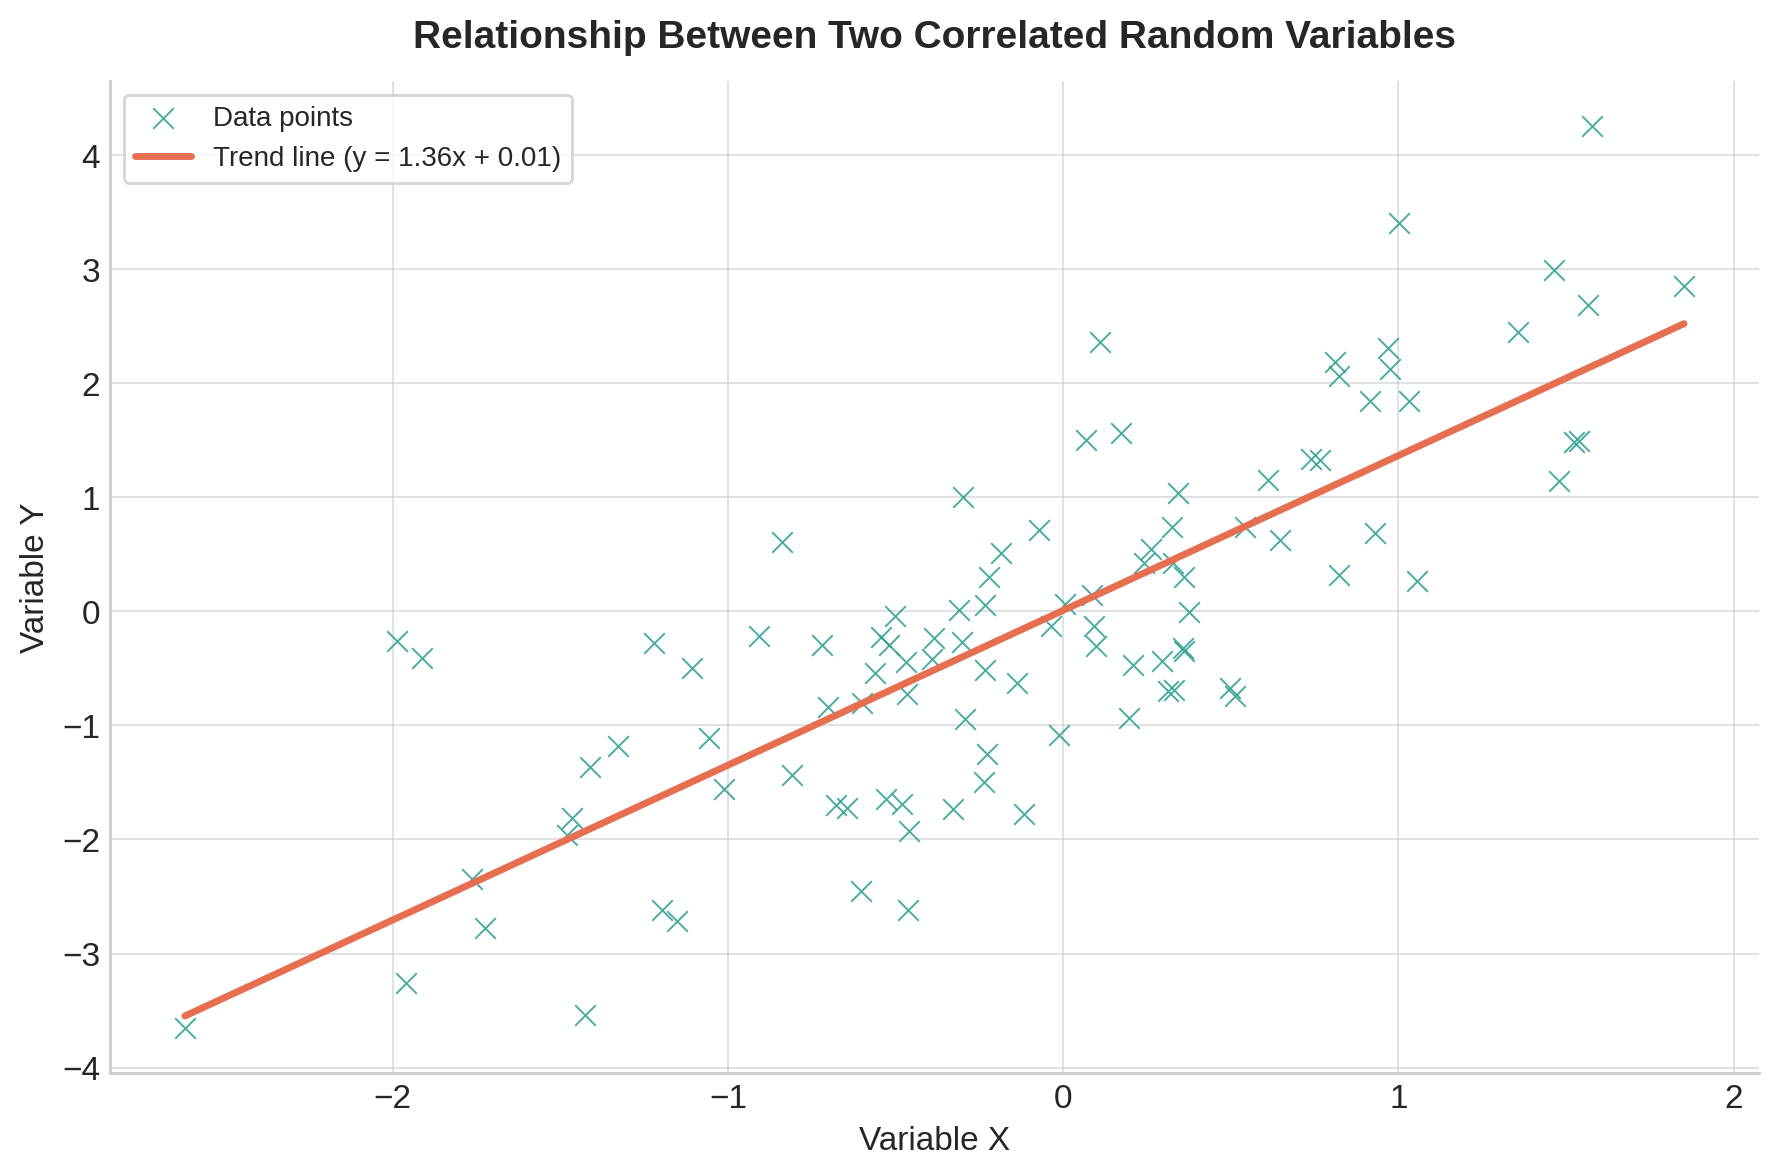

In [5]:
# Display Response and Generated Images
# Import the httpx library for making HTTP requests (used to download files from the container)
import httpx

# Helper function to download a file (such as images or data) from the code execution container
# given its container ID and file ID. Uses httpx to retrieve the raw file bytes (or None if download fails).
def download_file(container_id: str, file_id: str) -> bytes | None:
    """Download a file from the container."""
    url = f"https://api.openai.com/v1/containers/{container_id}/files/{file_id}/content"
    headers = {"Authorization": f"Bearer {api_key}"}
    with httpx.Client(timeout=60.0) as http_client:
        resp = http_client.get(url, headers=headers)
        resp.raise_for_status()
        return resp.content

# Print the text response
print("Assistant Response:")
print("-" * 40)
display(Markdown(response.output_text or ""))

# Iterate through the assistant's response output and search for the expected image file
# in "container_file_citation" annotations, then download and display it.
print("\nGenerated Images:")
print("=" * 40)
for output_item in response.output or []:
    for content in getattr(output_item, "content", []) or []:
        for annotation in getattr(content, "annotations", []) or []:
            if getattr(annotation, "type", None) == "container_file_citation":
                filename = getattr(annotation, "filename", "")
                if filename == "visualization.png":
                    print(filename)
                    img_bytes = download_file(annotation.container_id, annotation.file_id)
                    display(Image(data=img_bytes))


If the code in the previous cell ran successfully, you would now see your requested graph above. Sometimes, you may also see a direct download link to the image file (such as "visualization.png"), but note: this download link will not work because the agent only provides a link to its internal container storage, which is not directly accessible externally.

---

## Part 2: Working with Real-World Data

So far we used a toy task. Now we move to a **realistic workflow** that better reflects how agents can be used in practice.

In this example, we ask the agent to:
- Load **real streamflow data** for a US river from the **USGS website**
- **Parse** the downloaded data
- Create a plot of **one year of streamflow**
- Compare its own plot with the **official plot shown on the USGS website**
- Refine the plot by matching the USGS plot

The same LLM can be used to accomplish these later steps because the latest GPT models are **multimodal**: they can not only work with text and code, but can also interpret images.

### A practical note on data access

In this tutorial, the agent runs inside a **sandboxed execution environment**, which typically does **not have direct access to the internet**. While tools such as web search are useful for discovery and background knowledge, they are not reliable for downloading full datasets.

For this reason, we **download the data ourselves** and then **pass it to the agent** as part of the input. This still represents an **agentic workflow**: the reasoning, parsing, analysis, and refinement steps are performed by the agent and can be fully systematized.

More advanced setups are possible, but they are **beyond the scope of this tutorial**.

This brings us closer to how agents can support real engineering workflows: combining data access, code execution, visual understanding, and iterative refinement.


### Passing a Data URL to the Agent

To let the agent download real measurements, we can simply give it the **USGS data URL**.  
This URL already contains all the information needed to fetch the right dataset: *what variable*, *which site*, and *which time window*.

Example:

`https://waterdata.usgs.gov/nwis/dv?cb_00060=on&format=rdb&site_no=09380000&begin_date=2024-01-01&end_date=2025-12-31`

What each part means:

**Base path**
- `https://waterdata.usgs.gov/nwis/dv`  
USGS NWIS **Daily Values** endpoint (time series aggregated by day).

**Query parameters**
- `cb_00060=on`  
  Selects the variable with code **00060** (USGS parameter for **discharge / streamflow**).

- `format=rdb`  
  Requests the output in **RDB** format (a simple tab-delimited text format that is easy to parse in Python).

- `site_no=09380000`  
  The **USGS station ID** (the river gauge / measurement site).

- `begin_date=2024-01-01`  
  Start date of the requested time period (YYYY-MM-DD).

- `end_date=2025-12-31`  
  End date of the requested time period (YYYY-MM-DD).



In [6]:
# --- Inputs: choose catchment (USGS gauge) and time window ---
site_no = "09380000"          # USGS gauge / catchment ID
begin_date = "2024-01-01"     # YYYY-MM-DD
end_date   = "2025-12-31"     # YYYY-MM-DD

# --- Template URL for USGS NWIS Daily Values (discharge = parameter 00060) ---
USGS_DV_TEMPLATE = (
    "https://waterdata.usgs.gov/nwis/dv?"
    "cb_00060=on&format=rdb&site_no={site_no}&begin_date={begin_date}&end_date={end_date}"
)

usgs_url = USGS_DV_TEMPLATE.format(
    site_no=site_no,
    begin_date=begin_date,
    end_date=end_date,
)

print("USGS URL to feed to the agent:")
print(usgs_url)

USGS URL to feed to the agent:
https://waterdata.usgs.gov/nwis/dv?cb_00060=on&format=rdb&site_no=09380000&begin_date=2024-01-01&end_date=2025-12-31


In [7]:
import requests

# Download it from the internet with requests
headers = {"User-Agent": "my-usgs-fetch-script/1.0 (contact: you@example.com)"}
resp = requests.get(usgs_url, headers=headers, timeout=30)
resp.raise_for_status()

# Store it locally
local_path = "usgs_data.txt"
with open(local_path, "w") as f:
    f.write(resp.text)

# Open and check
with open(local_path, "r") as f:
    txt = f.read()

print(txt[:2000])

# ---------------------------------- WARNING ----------------------------------------
# Some of the data that you have obtained from this U.S. Geological Survey database 
# may not have received Director's approval. Any such data values are qualified
# as provisional and are subject to revision. Provisional data are released on the
# condition that neither the USGS nor the United States Government may be held liable
# for any damages resulting from its use.
#
# Additional info: https://waterdata.usgs.gov/provisional-data-statement/
#
# Contact:   gs-w_waterdata_support@usgs.gov
# retrieved: 2026-02-02 09:50:29 EST       (caww02)
#
# Data for the following 1 site(s) are contained in this file
#    USGS 09380000 COLORADO RIVER AT LEES FERRY, AZ
# -----------------------------------------------------------------------------------
#
# Data provided for site 09380000
#            TS   parameter     statistic     Description
#        236239       00060     00003     Discharge, cubic feet per

In [8]:
# Create a Code Interpreter Container
# Containers provide an isolated Python environment for code execution
container_name = f"usgs-agent-{uuid.uuid4().hex[:8]}"
container = client.containers.create(name=container_name)
container_id = container.id

print(f"✓ Container created: {container_name}")
print(f"  Container ID: {container_id}")

# Upload the USGS data file to the container
local_file_path = "usgs_data.txt"
with open(local_file_path, "rb") as f:
    uploaded_file = client.containers.files.create(
        container_id=container_id,
        file=f,
    )

print(f"✓ Uploaded '{local_file_path}' to container")


✓ Container created: usgs-agent-650a1fbe
  Container ID: cntr_6980b9be299481938be6ed3315e08728020f4bf862c73dcb
✓ Uploaded 'usgs_data.txt' to container


In [9]:
# Define System Prompt and User Prompt for USGS Data Visualization
SYSTEM_PROMPT = """You are a Python code execution assistant specialized in hydrological data analysis.
You help users by writing and executing Python code to download, process, and visualize water data.
Always save any generated files (figures, data, etc.) so they can be retrieved."""

img_file_name = f"usgs{site_no}_discharge_{begin_date}_{end_date}.png"

USER_PROMPT = f""" Create a figure of river discharge in time, from a given file containing data.

Sub-tasks:
1. Load usgs_data.txt, which is a RDB file.
2. Parse the file using Python tools
    - identify whether it is tab or comma separated
    - identify which lines are metadata, which lines have column headers and which lines have data  
    - store the name of the gauge and other geographical information of interest
3. Extract only the date and discharge (cfs - cubic feet per second) columns
4. Create a professional time series plot showing:
   - Daily discharge over time
   - Proper axis labels (Date, Discharge in cfs)
   - A descriptive title mentioning the river name and other information you retrieved from the header
5. Use a visually appealing color scheme (not default matplotlib colors)
6. Save the figure as {img_file_name} at high resolution (dpi=150)
7. Print summary statistics: min, max, mean discharge and identify peak flow dates
"""
  
print("\nUser Prompt:")
print("-" * 50)
print(USER_PROMPT[:3000] + "...")



User Prompt:
--------------------------------------------------
 Create a figure of river discharge in time, from a given file containing data.

Sub-tasks:
1. Load usgs_data.txt, which is a RDB file.
2. Parse the file using Python tools
    - identify whether it is tab or comma separated
    - identify which lines are metadata, which lines have column headers and which lines have data  
    - store the name of the gauge and other geographical information of interest
3. Extract only the date and discharge (cfs - cubic feet per second) columns
4. Create a professional time series plot showing:
   - Daily discharge over time
   - Proper axis labels (Date, Discharge in cfs)
   - A descriptive title mentioning the river name and other information you retrieved from the header
5. Use a visually appealing color scheme (not default matplotlib colors)
6. Save the figure as usgs09380000_discharge_2024-01-01_2025-12-31.png at high resolution (dpi=150)
7. Print summary statistics: min, max, mean 

In [10]:
# Send Request to OpenAI with Code Interpreter

# Build the input payload
input_payload = [
    {
        "role": "system",
        "content": [{"type": "input_text", "text": SYSTEM_PROMPT}],
    },
    {
        "role": "user", 
        "content": [{"type": "input_text", "text": USER_PROMPT}],
    },
]

# Make the API call with code interpreter tool
print("Sending request to OpenAI...")
print("(This may take some time as the model generates and executes code)\n")

response = client.responses.create(
    model="gpt-5.2",
    input=input_payload,
    tools=[
        {"type": "code_interpreter", "container": container_id},        ],
    tool_choice="required",  # Force the model to use the code interpreter
)

print("✓ Response received!")

Sending request to OpenAI...
(This may take some time as the model generates and executes code)

✓ Response received!


Assistant Response:
----------------------------------------


### Parsed file (USGS RDB)
- **Delimiter:** tab-separated (`\t`)
- **Metadata lines:** lines starting with `#`
- **Column header line:** line 26 in the file (0-based index `25`)
- **Format-spec line:** line 27 (0-based index `26`, e.g., `5s 15s 20d 14n ...`)
- **Gauge / station info from header:**
  - **Site no:** `09380000`
  - **Station name:** `COLORADO RIVER AT LEES FERRY, AZ`

### Extracted columns
- **Date column:** `datetime`
- **Discharge column (cfs):** `236239_00060_00003` (USGS parameter code `00060` = discharge)

### Output figure
Saved at high resolution (dpi=150) as requested:  
[Download the figure](sandbox:/mnt/data/usgs09380000_discharge_2024-01-01_2025-12-31.png)

### Summary statistics (daily discharge, cfs)
- **Min:** 6,880 cfs  
- **Max:** 12,800 cfs  
- **Mean:** 10,302.37 cfs  

**Peak flow date(s):**
- 2025-02-27 (12,800 cfs)


Generated Images:
usgs09380000_discharge_2024-01-01_2025-12-31.png


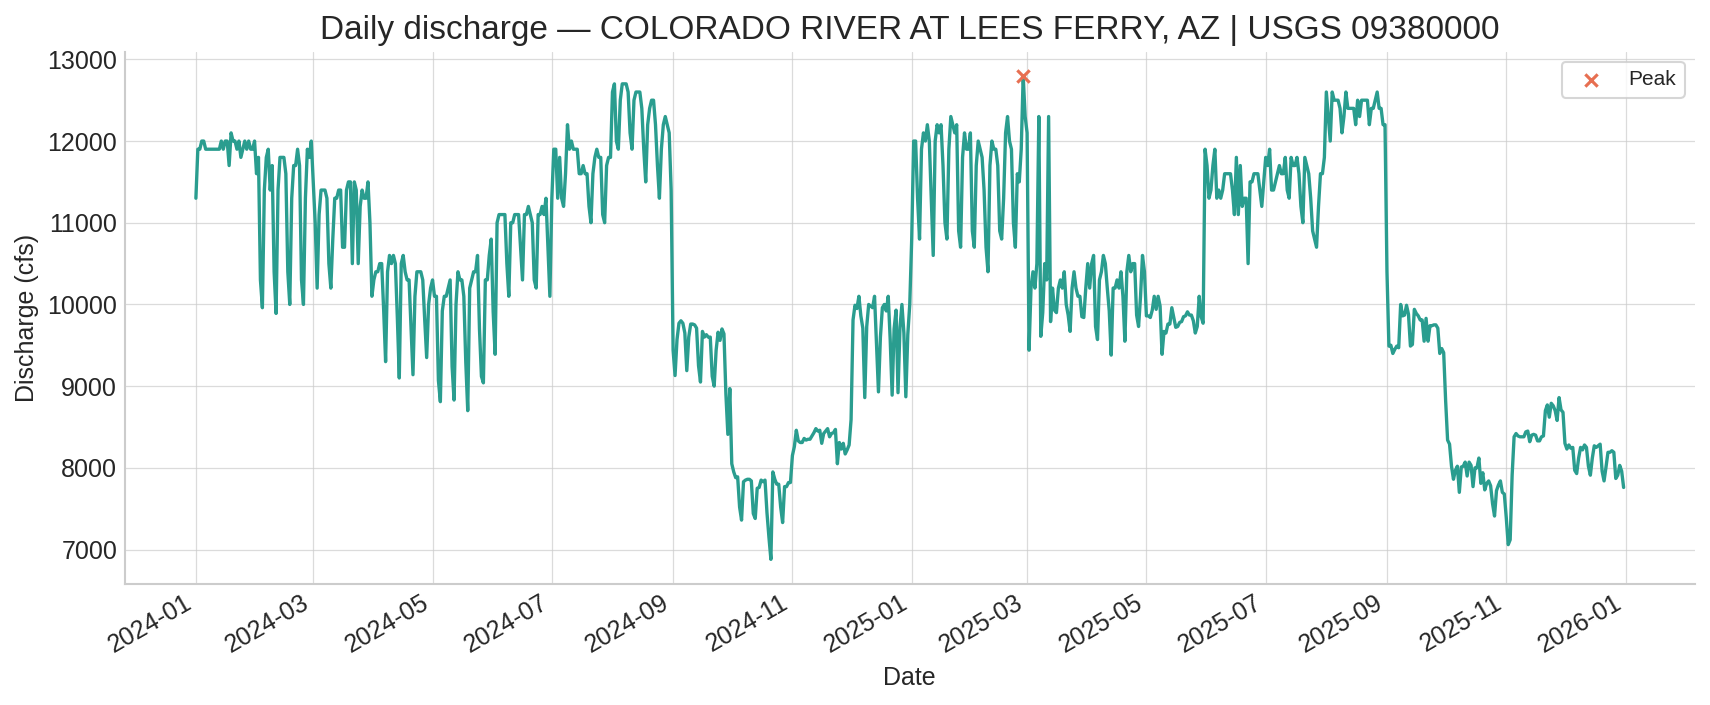

In [11]:
# Print the text response
print("Assistant Response:")
print("-" * 40)
display(Markdown(response.output_text or ""))

# Iterate through the assistant's response output and search for any image files referenced
# in "container_file_citation" annotations, then download and display each found image.
print("\nGenerated Images:")
print("=" * 40)
for output_item in response.output or []:
    for content in getattr(output_item, "content", []) or []:
        for annotation in getattr(content, "annotations", []) or []:
            if getattr(annotation, "type", None) == "container_file_citation":
                filename = getattr(annotation, "filename", "")
                print(filename)
                if filename == img_file_name:
                    img_bytes = download_file(annotation.container_id, annotation.file_id)
                    display(Image(data=img_bytes))

### Compare with Official USGS Statistics

Now we ask the model to use **web search** to retrieve and analyze the official USGS statistics page, which contains a graph and summary statistics for the same gauge and time period.

In [14]:
# Construct the USGS statistics page URL
usgs_stats_url = (
    f"https://waterdata.usgs.gov/az/nwis/dv?"
    f"cb_00060=on&format=gif_default&site_no={site_no}&legacy="
    f"&referred_module=sw&period=&begin_date={begin_date}&end_date={end_date}"
)

print("USGS Statistics URL:")
print(usgs_stats_url)

USGS Statistics URL:
https://waterdata.usgs.gov/az/nwis/dv?cb_00060=on&format=gif_default&site_no=09380000&legacy=&referred_module=sw&period=&begin_date=2024-01-01&end_date=2025-12-31


In [35]:
# Step 1: Ask GPT to extract the GIF image URL from the USGS page
EXTRACT_PROMPT = f"""Visit this USGS page and extract the URL of the discharge graph image:

{usgs_stats_url}

Task:
- Find the GIF image that shows the discharge graph
- Return ONLY the full URL of the image (nothing else)
"""

print("Extract Image URL Prompt:")
print("-" * 50)
print(EXTRACT_PROMPT)

Extract Image URL Prompt:
--------------------------------------------------
Visit this USGS page and extract the URL of the discharge graph image:

https://waterdata.usgs.gov/az/nwis/dv?cb_00060=on&format=gif_default&site_no=09380000&legacy=&referred_module=sw&period=&begin_date=2024-01-01&end_date=2025-12-31

Task:
- Find the GIF image that shows the discharge graph
- Return ONLY the full URL of the image (nothing else)



In [36]:
# Call the model with web search to extract the image URL
extract_payload = [
    {
        "role": "system",
        "content": [{"type": "input_text", "text": "You are a helpful assistant that extracts information from web pages."}],
    },
    {
        "role": "user",
        "content": [{"type": "input_text", "text": EXTRACT_PROMPT}],
    },
]

print("Sending request to OpenAI with web search...")
print("(This may take some time)\n")

extract_response = client.responses.create(
    model="gpt-5.2",
    input=extract_payload,
    tools=[{"type": "web_search"}],
)

print("✓ Response received!")

Sending request to OpenAI with web search...
(This may take some time)

✓ Response received!


In [37]:
# Display the extracted image URL
print("Extracted Image URL:")
print("=" * 50)
usgs_gif_url = extract_response.output_text.strip()
print(usgs_gif_url)

Extracted Image URL:
https://natwebcaww02.wr.usgs.gov/nwisweb/data/img/USGS.09380000.236239.00060.00003.20240101.20251231.log.0..gif


### Download USGS Image and Upload to Container

Now we download the official USGS discharge graph and upload it to the container so the model can analyze it with vision.

In [38]:
# Download the USGS GIF image locally
usgs_image_path = "usgs_official_graph.gif"

print(f"Downloading USGS image from: {usgs_gif_url}")
img_response = requests.get(usgs_gif_url, headers=headers, timeout=30)
img_response.raise_for_status()

with open(usgs_image_path, "wb") as f:
    f.write(img_response.content)

print(f"✓ Image saved locally as '{usgs_image_path}'")
print(f"  Size: {len(img_response.content)} bytes")

✓ Image saved locally as 'usgs_official_graph.gif'
  Size: 6219 bytes


In [39]:
# Upload the USGS image to the container
with open(usgs_image_path, "rb") as f:
    client.containers.files.create(
        container_id=container_id,
        file=f,
    )

print(f"✓ Uploaded '{usgs_image_path}' to container")

✓ Uploaded 'usgs_official_graph.gif' to container


In [45]:
# Create prompt for vision analysis and plot modification
VISION_PROMPT = f"""Analyze the official USGS discharge graph and modify your plot to match its style.

Reference image: {usgs_image_path} (official USGS graph)
Your original plot: {img_file_name}

Tasks:
1. Using your Vision capabilities
   - Describe the visual style: colors, line thickness, axes formatting
   - Note the axis labels, title format, and any annotations
   - Identify the scale type (linear vs logarithmic)

2. Open your original plot ({img_file_name}) and compare
   - List the key differences in style and formatting

3. Recreate the discharge plot to closely match the USGS style:
   - Match the color scheme and line style
   - Match the axis formatting and labels
   - Match the title style
   - Use the same scale type (log if USGS uses log)
   - Save as 'MODIFIED_{img_file_name}'
"""

print("Vision Analysis Prompt:")
print("-" * 50)
print(VISION_PROMPT)

Vision Analysis Prompt:
--------------------------------------------------
Analyze the official USGS discharge graph and modify your plot to match its style.

Reference image: usgs_official_graph.gif (official USGS graph)
Your original plot: usgs09380000_discharge_2024-01-01_2025-12-31.png

Tasks:
1. Using your Vision capabilities
   - Describe the visual style: colors, line thickness, axes formatting
   - Note the axis labels, title format, and any annotations
   - Identify the scale type (linear vs logarithmic)

2. Open your original plot (usgs09380000_discharge_2024-01-01_2025-12-31.png) and compare
   - List the key differences in style and formatting

3. Recreate the discharge plot to closely match the USGS style:
   - Match the color scheme and line style
   - Match the axis formatting and labels
   - Match the title style
   - Use the same scale type (log if USGS uses log)
   - Save as 'MODIFIED_usgs09380000_discharge_2024-01-01_2025-12-31.png'



In [46]:
# Call the model with vision and code interpreter
vision_payload = [
    {
        "role": "system",
        "content": [{"type": "input_text", "text": "You are a data visualization expert. Analyze images and write Python code to recreate plots matching specific styles."}],
    },
    {
        "role": "user",
        "content": [{"type": "input_text", "text": VISION_PROMPT}],
    },
]

print("Sending request to OpenAI with vision + code interpreter...")
print("(This may take some time)\n")

vision_response = client.responses.create(
    model="gpt-5.2",
    input=vision_payload,
    tools=[{"type": "code_interpreter", "container": container_id}],
    tool_choice="required",
)

print("✓ Response received!")

Sending request to OpenAI with vision + code interpreter...
(This may take some time)



✓ Response received!


Vision Analysis Results:


## 1) USGS official graph style (from `usgs_official_graph.gif`)

**Overall look**
- **White background** with a **medium-gray grid**.
- Grid is fairly prominent: **major gridlines** are darker/thicker; **minor horizontal gridlines** are lighter/thinner.

**Data series styling**
- Primary discharge line: **bright USGS-blue** (pure-looking blue), **thin** line.
- Estimated values: shown as **red** segments (thin), overlaid on the same time series.

**Axes / ticks**
- **Y-axis label** is **bold**, all-caps “DAILY …”, reads:  
  **`DAILY Discharge, cubic feet per second`**
- Y ticks appear bold, with major ticks at **6000, 10000, 20000** (and grid subdivisions in between).
- X ticks are **quarterly** and formatted as **two-line labels**:  
  `Jan` (top line) and `2024` (bottom line), then `Apr`, `Jul`, `Oct`, etc.
- Axis spines are **black and relatively thick**, giving a framed look.

**Title / header**
- Single bold header centered at top:  
  **`USGS 09380000 COLORADO RIVER AT LEES FERRY, AZ`**
- No subtitle in the official GIF (it’s a single header line in the plot area).

**Annotations / extra elements**
- At the bottom of the plot area there’s a **status bar**:
  - **Green**: “Period of approved data”
  - **Magenta**: “Period of provisional data”
- Legend sits **below the plot**, with **4 entries**:
  1) Daily mean discharge (blue)
  2) Estimated daily mean discharge (red)
  3) Period of approved data (green)
  4) Period of provisional data (magenta)

**Scale type**
- **Linear** y-axis (not logarithmic).

---

## 2) Differences vs your original plot (`usgs09380000_discharge_2024-01-01_2025-12-31.png`)

Key differences I see:

- **Color**: your line is **teal/greenish**; USGS uses **bright blue** (and red only for estimated segments).
- **Legend**: your plot includes a **“Peak”** marker/legend entry; USGS does **not** show a peak marker.
- **Title format**: yours is a modern sentence-style title; USGS uses an **all-caps bold station header**.
- **X-axis formatting**: yours uses **angled date labels**; USGS uses **quarterly ticks with stacked Month/Year**.
- **Grid and frame**: yours has a lighter/modern grid and minimal framing; USGS has a **stronger grid** and **thicker black spines**.
- **Status bars**: USGS includes **approved/provisional color bars** at the bottom; your original does not.
- **Typography**: USGS uses **bold tick labels** and heavier axis label styling.

---

## 3) Recreated plot matching USGS style

I recreated the plot to closely match the official USGS styling (blue discharge line, red estimated segments, bold station header, quarterly month/year ticks, heavier grid/frame, and approved/provisional bars + legend).

Saved as:
[Download MODIFIED_usgs09380000_discharge_2024-01-01_2025-12-31.png](sandbox:/mnt/data/MODIFIED_usgs09380000_discharge_2024-01-01_2025-12-31.png)


Searching for modified image...
Found file: cfile_6980c36039d08191a2b56e2c63e921c2.png
Found file: cfile_6980c3603ae08191b2d1929331303a11.png
Found file: MODIFIED_usgs09380000_discharge_2024-01-01_2025-12-31.png
✓ Downloaded MODIFIED_usgs09380000_discharge_2024-01-01_2025-12-31.png


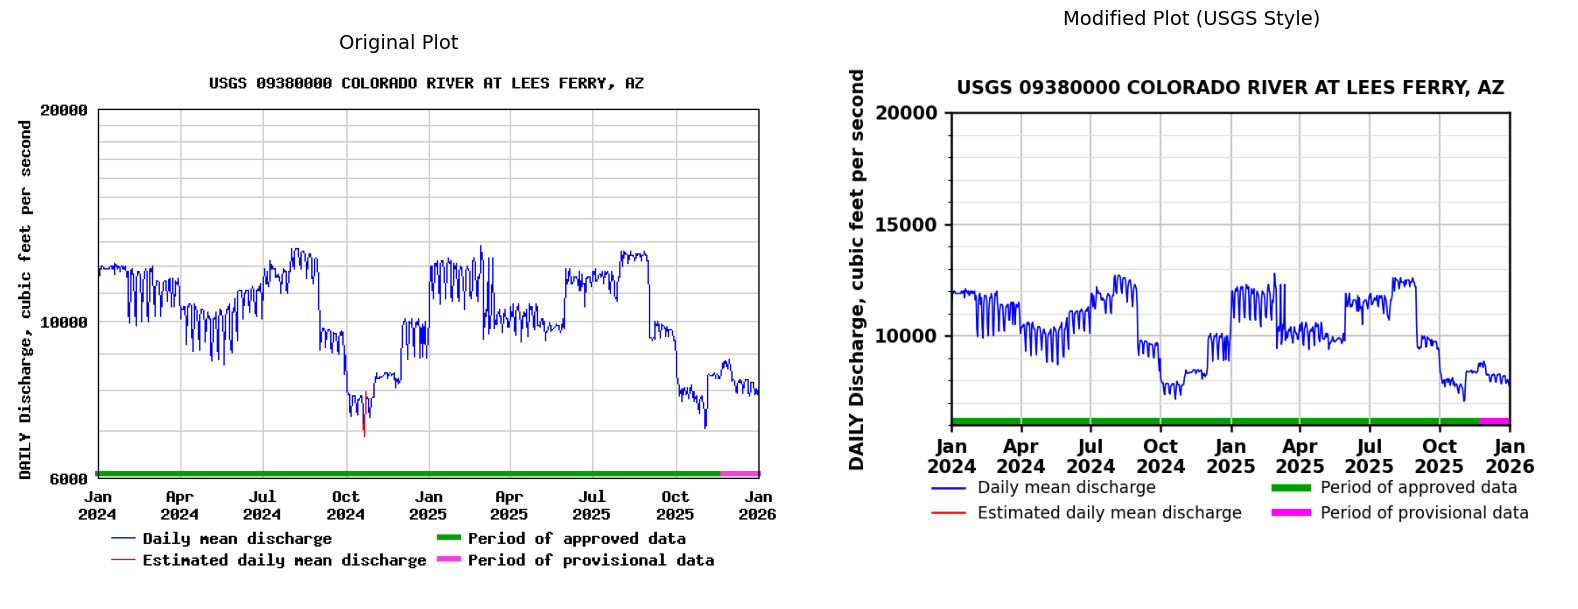

In [50]:
# Display the vision analysis and modified plot
print("Vision Analysis Results:")
print("=" * 50)
display(Markdown(vision_response.output_text or ""))

# Retrieve the modified image from the container
print("\nSearching for modified image...")
modified_img_name = f"MODIFIED_{img_file_name}"
modified_img_bytes = None

for output_item in vision_response.output or []:
    for content in getattr(output_item, "content", []) or []:
        for annotation in getattr(content, "annotations", []) or []:
            if getattr(annotation, "type", None) == "container_file_citation":
                filename = getattr(annotation, "filename", "")
                print(f"Found file: {filename}")
                if filename == modified_img_name:
                    modified_img_bytes = download_file(annotation.container_id, annotation.file_id)
                    print(f"✓ Downloaded {modified_img_name}")

# Plot original and modified side by side
if modified_img_bytes:
    import matplotlib.pyplot as plt
    import matplotlib.image as mpimg
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Load and display original plot
    original_img = mpimg.imread(usgs_image_path)
    axes[0].imshow(original_img)
    axes[0].set_title("Original Plot", fontsize=14)
    axes[0].axis("off")
    
    # Load and display modified plot
    modified_img = mpimg.imread(BytesIO(modified_img_bytes))
    axes[1].imshow(modified_img)
    axes[1].set_title("Modified Plot (USGS Style)", fontsize=14)
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Modified image not found in response")

try to 
1) the provisional data period visualize seems correct, but how does the model know? is it an approxiamte estimation from its vision capability, or is the model using the column "status" from the original data to recreate it?
2) how does the model know how t ocreate the plot (i.e., which data); we did not store that prompt inside the model for it to know, it might have guess it? we can ask the code back from the model to understand this
2) another river, another period
